## Annotation

This project will try to explore the global landscape of the software development industry using data from the 2025 Stack Overflow Developer Survey. The primary purpose of the project is to analyze the relationships between a developer's experience, education level, adoption of AI tools, and their annual compensation. This will be achieved by performing exploratory data analysis and statistical analysis.

Project's team consisted of only one member: Eylkin Svyatoslav from group 252-1.

## Dataset Description

The subject area of the dataset is the technology and software development industry. The dataset is derived from the annual [Stack Overflow Developer Survey](https://github.com/StackExchange/Survey/tree/main), which captures responses from around 50k developers worldwide. The dataset contains numerous fields, including categorical fields (e.g., `EdLevel` for education, `AISelect` for AI usage stance, `ICorPM` for Individual Contributor vs. People Manager) and numerical fields (e.g., `ConvertedCompYearly` for USD salary, `WorkExp` for professional coding years, `YearsCode` for total coding years, `ToolsWork` for the number of distinct apps used at work, and `ToolsSide` for apps used on side projects). 

I want to first focus on these columns:
1.  `ConvertedCompYearly` (Annual Compensation)
2.  `WorkExp` (Years of professional work experience)
3.  `YearsCode` (Total years coding)
4.  `ToolCountWork` (Distinct software applications used for the job)
5.  `ToolCountPersonal` (Distinct software applications used for side projects)
6.  `EdLevel` (Education)
7.  `AISelect` (Do you currently use AI tools...?)
8.  `ICorPM` (Individual contributor or People manager)

P.S.
When refering to salary in the code/text later I mean *Annual Compensation*.

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [37]:
df = pd.read_csv("./data/sof_survey_2025.csv")
df.head(2)

/tmp/ipykernel_41384/724876503.py:1: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/sof_survey_2025.csv")


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,JobSatPoints_15_TEXT,AIThreat,NewRole,ToolCountWork,ToolCountPersonal,Country,Currency,CompTotal,LanguageChoice,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,LanguagesHaveEntry,LanguagesWantEntry,DatabaseChoice,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,DatabaseHaveEntry,DatabaseWantEntry,PlatformChoice,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,PlatformHaveEntry,PlatformWantEntry,WebframeChoice,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,WebframeHaveEntry,WebframeWantEntry,DevEnvsChoice,DevEnvsHaveWorkedWith,DevEnvsWantToWorkWith,DevEnvsAdmired,DevEnvHaveEntry,DevEnvWantEntry,SOTagsHaveWorkedWith,SOTagsWantToWorkWith,SOTagsAdmired,SOTagsHaveEntry,SOTagsWant Entry,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackHaveEntry,OfficeStackWantEntry,CommPlatformHaveWorkedWith,CommPlatformWantToWorkWith,CommPlatformAdmired,CommPlatformHaveEntr,CommPlatformWantEntr,AIModelsChoice,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.00,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.00,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.00,7.00,9.00,6.00,3.00,11.00,12.00,1.00,8.00,14.00,NaN,15.00,7.00,8.00,12.00,11.00,1.00,6.00,13.00,3.00,16.00,NaN,Fintech,3.00,1.00,4.00,9.00,5.00,10.00,12.00,11.00,2.00,6.00,7.00,13.00,14.00,15.00,8.00,NaN,I'm not sure,I have neither consider or transitioned into a...,7.00,3.00,Ukraine,EUR European Euro,"52,800.00",Yes,Bash/Shell (all shells);Dart;SQL,Dart,Dart,NaN,NaN,Yes,Cloud Firestore;PostgreSQL,NaN,NaN,NaN,NaN,Yes,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,Yes,Android Studio;Notepad++;Visual Studio;Visual ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Windows;MacOS;Android,Windows;MacOS;Android;iOS;

In [38]:
df.shape

(49191, 172)

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), str(119)
memory usage: 176.2 MB


In [40]:
key_columns = [
    "ConvertedCompYearly",
    "WorkExp",
    "YearsCode",
    "EdLevel",
    "AISelect",
    "ICorPM",
    "ToolCountWork",
    "ToolCountPersonal",
]

display(df[key_columns].info())

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ConvertedCompYearly  23947 non-null  float64
 1   WorkExp              42893 non-null  float64
 2   YearsCode            43042 non-null  float64
 3   EdLevel              48149 non-null  str    
 4   AISelect             33720 non-null  str    
 5   ICorPM               33243 non-null  str    
 6   ToolCountWork        27611 non-null  float64
 7   ToolCountPersonal    25582 non-null  float64
dtypes: float64(5), str(3)
memory usage: 6.8 MB


None

In [41]:
df[key_columns].describe()

,ConvertedCompYearly,WorkExp,YearsCode,ToolCountWork,ToolCountPersonal
count,"23,947.00","42,893.00","43,042.00","27,611.00","25,582.00"
mean,"101,761.54",13.37,16.57,17.73,8.55
std,"461,756.90",10.80,11.79,269.81,44.66
min,1.00,1.00,1.00,0.00,0.00
25%,"38,171.00",5.00,8.00,4.00,3.00
50%,"75,320.00",10.00,14.00,6.00,5.00
75%,"120,596.00",20.00,24.00,10.00,7.00
max,"50,000,000.00",100.00,100.00,"10,000.00","1,000.00"


In [42]:
df[key_columns].describe(include="object")

/tmp/ipykernel_41384/3054426358.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df[key_columns].describe(include="object")


,EdLevel,AISelect,ICorPM
count,48149,33720,33243
unique,8,5,2
top,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Yes, I use AI tools daily",Individual contributor
freq,20278,15883,28341



## Data Cleanup and Transformation

In [43]:
key_df = df[key_columns]

In [44]:
df_check = pd.DataFrame(
    {
        "dtype": key_df.dtypes.astype(str),
        "missing_count": key_df.isna().sum(),
        "missing_percent": key_df.isna().mean() * 100,
        "unique_values": key_df.nunique(dropna=True),
    }
)
df_check.sort_values("missing_count", ascending=False)

,dtype,missing_count,missing_percent,unique_values
ConvertedCompYearly,float64,25244,51.32,6237
ToolCountPersonal,float64,23609,47.99,87
ToolCountWork,float64,21580,43.87,114
ICorPM,str,15948,32.42,2
AISelect,str,15471,31.45,5
WorkExp,float64,6298,12.80,72
YearsCode,float64,6149,12.50,78
EdLevel,str,1042,2.12,8


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.isna().sum().sort_values(ascending=False)

AIAgentObsWrite      48927
SOTagsWant Entry     48761
SOTagsHaveEntry      48733
AIModelsWantEntry    48716
AIAgentOrchWrite     48713
                     ...  
EdLevel               1042
Employment             852
ResponseId               0
MainBranch               0
Age                      0
Length: 172, dtype: int64

We remove rows which do not contain critical information for our analysis.
Note: We intentionally DO NOT drop NaNs in the 'ToolCount' columns yet, because they are optional survey questions. Dropping them here would accidentally delete tens of thousands of valid salaries.

In [47]:
critical_cols = [
    "ConvertedCompYearly",
    "WorkExp",
    "YearsCode",
    "EdLevel",
    "AISelect",
    "ICorPM",
]
df_clean = df.dropna(subset=critical_cols).copy()

Now we remove extreme outliers using IQR.

In [48]:
cols_to_filter = [
    "ConvertedCompYearly",
    "ToolCountWork",
    "ToolCountPersonal",
]

for col in cols_to_filter:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    l = max(0, q1 - 1.5 * iqr)
    u = q3 + 1.5 * iqr

    df_clean = df_clean[
        ((df_clean[col] >= l) & (df_clean[col] <= u)) | df_clean[col].isna()
    ]

In [49]:
print(
    f"Removed {(df.shape[0] - df_clean.shape[0])} rows containing missing values or extreme outliers."
)

Removed 32402 rows containing missing values or extreme outliers.


In [50]:
df_clean.to_csv("cleaned_survey_data.csv", index=False)

Now we add two new rows for the ease of later analysis:
- **`YearsCodeHobby`**: Equals to `YearsCode` - `WorkExp`. This gives us an estimate of how long a developer coded recreationally or academically before working professionally.
- **`EdLevel_Numeric`**: We want to convert categorical values of the `EdLevel` column to a numerical scale, so that we can you use this data in our analysis. The conversion rates: Primary School = 1, Secondary school = 2, Some college/university = 3, Associate degree = 4, Bachelor's degree = 5, Master's degree = 6, Professional Degree = 7.

In [51]:
df_clean["YearsCodeHobby"] = df_clean["YearsCode"] - df_clean["WorkExp"]
df_clean["YearsCodeHobby"] = df_clean["YearsCodeHobby"].apply(
    lambda x: x if x >= 0 else 0
)

In [52]:
ed_mapping = {
    "Primary/elementary school": 1,
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 2,
    "Some college/university study without earning a degree": 3,
    "Associate degree (A.A., A.S., etc.)": 4,
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": 5,
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": 6,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 7,
}

df_clean["EdLevel_Numeric"] = df_clean["EdLevel"].map(ed_mapping)

In [53]:
display(
    df_clean[
        ["YearsCode", "WorkExp", "YearsCodeHobby", "EdLevel", "EdLevel_Numeric"]
    ].sample(5)
)

,YearsCode,WorkExp,YearsCodeHobby,EdLevel,EdLevel_Numeric
11652,10.00,2.00,8.00,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.00
39399,4.00,4.00,0.00,"Secondary school (e.g. American high school, G...",2.00
45192,8.00,8.00,0.00,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.00
44809,20.00,30.00,0.00,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",6.00
37150,5.00,1.00,4.00,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.00


In [54]:
key_columns.append("YearsCodeHobby")
key_columns.append("EdLevel_Numeric")
display(df_clean[key_columns].info())

<class 'pandas.DataFrame'>
Index: 16789 entries, 0 to 49121
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ConvertedCompYearly  16789 non-null  float64
 1   WorkExp              16789 non-null  float64
 2   YearsCode            16789 non-null  float64
 3   EdLevel              16789 non-null  str    
 4   AISelect             16789 non-null  str    
 5   ICorPM               16789 non-null  str    
 6   ToolCountWork        14105 non-null  float64
 7   ToolCountPersonal    12466 non-null  float64
 8   YearsCodeHobby       16789 non-null  float64
 9   EdLevel_Numeric      16649 non-null  float64
dtypes: float64(7), str(3)
memory usage: 3.0 MB


None

## EDA
To understand the distributions and basic relations between the key numerical fields: `ConvertedCompYearly`, `ToolCountWork`, `YearsCodeHobby`, `WorkExp`, were created some visualizations using four different plot types:

- **Histogram**: for `ConvertedCompYearly` to observe the distribution of global developer salaries (revealing a heavy right-skew).
- **Boxplot**: for `ToolCountWork` to visualize the spread, median, and variance of the number of distinct tools used at work, which also serves to visually verify our IQR outlier cleanup.
- **Scatter plot**: `YearsCodeHobby` vs `ConvertedCompYearly` to explore the variance and density of pre-professional coding experience and its initial lack of clear linear correlation with current salary.
- **Line plot**: `ConvertedCompYearly` over `WorkExp` to track the average salary trajectory and its confidence interval as professional experience increases over time.

Additionally key indicators were calculated and analysed.

In [55]:
num_columns = [
    "ConvertedCompYearly",
    "WorkExp",
    "ToolCountWork",
    "ToolCountPersonal",
    "YearsCodeHobby",
    "YearsCode",
    "EdLevel_Numeric",
]

stats_df = df_clean[num_columns].describe().T

stats_df = stats_df[["mean", "50%", "std"]]
stats_df.rename(columns={"50%": "median"}, inplace=True)

pd.options.display.float_format = "{:,.2f}".format

display(stats_df)

,mean,median,std
ConvertedCompYearly,"80,284.58","72,393.00","55,159.71"
WorkExp,12.75,10.00,9.47
ToolCountWork,6.67,6.00,3.59
ToolCountPersonal,4.28,4.00,2.50
YearsCodeHobby,4.79,4.00,4.22
YearsCode,16.99,15.00,10.41
EdLevel_Numeric,4.99,5.00,1.22


In [56]:
print("\tEducation Level vs AI Usage")
ai_edu_pivot = df_clean[df_clean["EdLevel_Numeric"].isin([5.0, 6.0])].copy()
ai_edu_pivot["Education"] = ai_edu_pivot["EdLevel_Numeric"].map(
    {5.0: "Bachelor", 6.0: "Master"}
)

ai_edu_pivot = ai_edu_pivot[
    ai_edu_pivot["AISelect"].isin(
        ["Yes, I use AI tools daily", "No, and I don't plan to"]
    )
]
print(
    ai_edu_pivot.groupby(["Education", "AISelect"])["ConvertedCompYearly"]
    .median()
    .unstack()
)

	Education Level vs AI Usage
AISelect   No, and I don't plan to  Yes, I use AI tools daily
Education                                                    
Bachelor                 85,769.00                  66,458.00
Master                   78,962.00                  75,410.00


In [57]:
print("\tMedian Salary: Tool Bloat vs Role")
df_clean["Tool_Bin"] = pd.cut(
    df_clean["ToolCountWork"],
    bins=[-1, 5, 10, 100],
    labels=["Low (0-5)", "Medium (6-10)", "High (>10)"],
)
print(
    df_clean.groupby(["ICorPM", "Tool_Bin"], observed=False)["ConvertedCompYearly"]
    .median()
    .unstack()
)

	Median Salary: Tool Bloat vs Role
Tool_Bin                Low (0-5)  Medium (6-10)  High (>10)
ICorPM                                                      
Individual contributor  64,950.50      75,307.00   87,550.00
People manager          75,410.00      92,547.00   91,013.00


In [58]:
print("\tMedian Salary: Hobby Experience vs AI Usage")
df_clean["Hobby_Bin"] = pd.cut(
    df_clean["YearsCodeHobby"],
    bins=[-1, 3, 8, 100],
    labels=["Low (0-3 yrs)", "Medium (4-8 yrs)", "High (>8 yrs)"],
)
hobby_ai_pivot = df_clean[
    df_clean["AISelect"].isin(["Yes, I use AI tools daily", "No, and I don't plan to"])
]
print(
    hobby_ai_pivot.groupby(["Hobby_Bin", "AISelect"], observed=False)[
        "ConvertedCompYearly"
    ]
    .median()
    .unstack()
)

	Median Salary: Hobby Experience vs AI Usage
AISelect          No, and I don't plan to  Yes, I use AI tools daily
Hobby_Bin                                                           
Low (0-3 yrs)                   75,410.00                  58,007.00
Medium (4-8 yrs)                78,005.50                  71,168.00
High (>8 yrs)                   82,319.00                  87,763.00


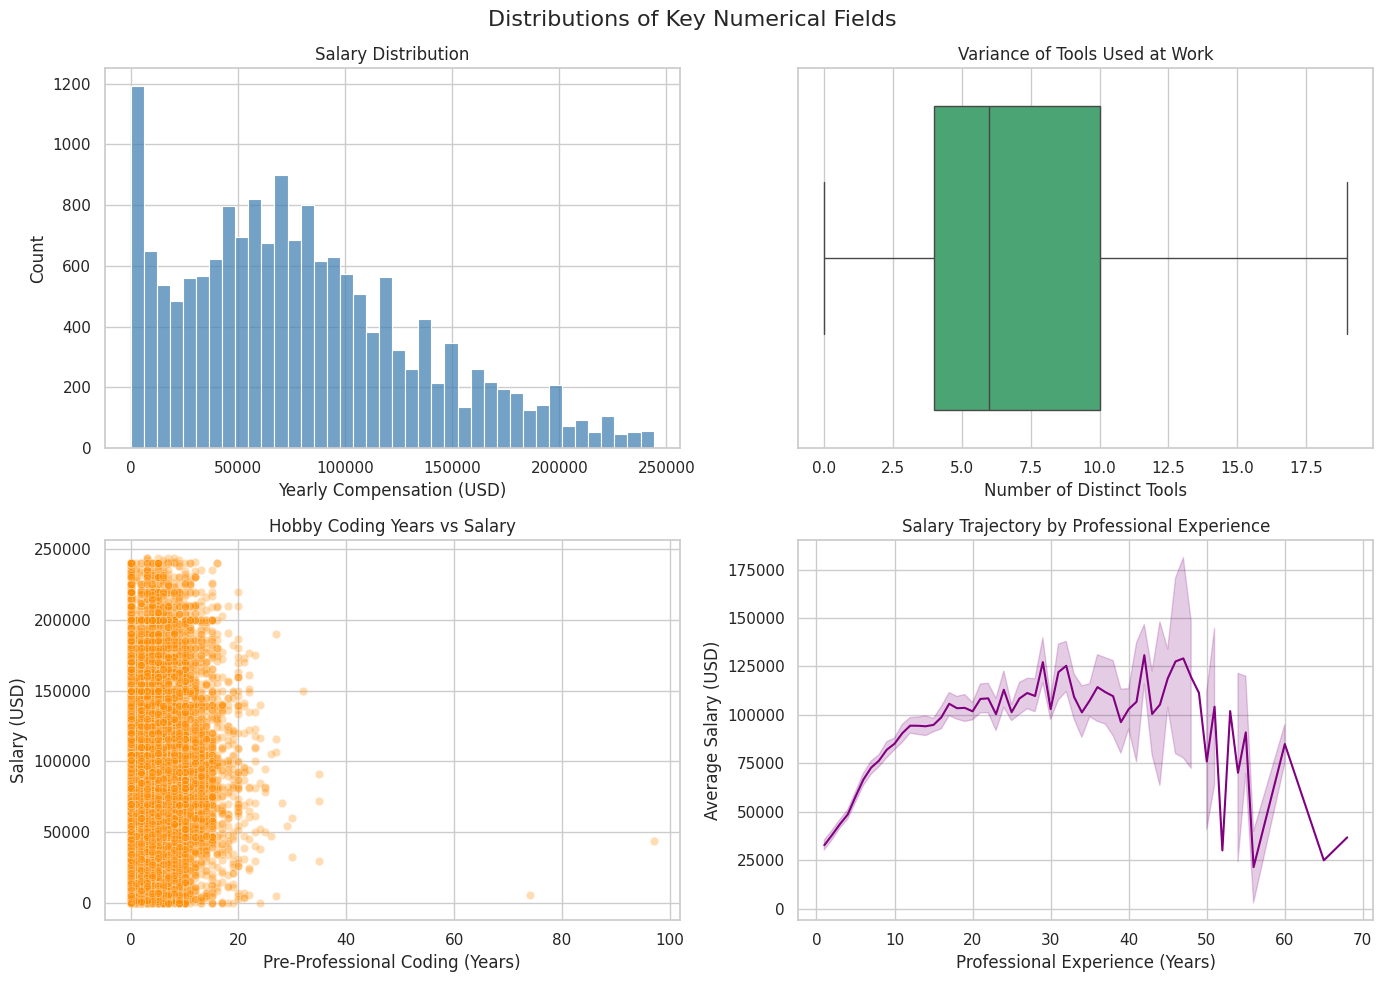

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distributions of Key Numerical Fields", fontsize=16)

# 1. Salary Distribution
sns.histplot(df_clean["ConvertedCompYearly"], bins=40, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Salary Distribution")
axes[0, 0].set_xlabel("Yearly Compensation (USD)")

# 2. Tools at Work
sns.boxplot(x=df_clean["ToolCountWork"], ax=axes[0, 1], color="mediumseagreen")
axes[0, 1].set_title("Variance of Tools Used at Work")
axes[0, 1].set_xlabel("Number of Distinct Tools")

# 3. Hobby Coding vs Salary
sns.scatterplot(
    x="YearsCodeHobby",
    y="ConvertedCompYearly",
    data=df_clean,
    alpha=0.3,
    color="darkorange",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Hobby Coding Years vs Salary")
axes[1, 0].set_xlabel("Pre-Professional Coding (Years)")
axes[1, 0].set_ylabel("Salary (USD)")

# 4. Salary Trajectory
sns.lineplot(
    x="WorkExp", y="ConvertedCompYearly", data=df_clean, color="purple", ax=axes[1, 1]
)
axes[1, 1].set_title("Salary Trajectory by Professional Experience")
axes[1, 1].set_xlabel("Professional Experience (Years)")
axes[1, 1].set_ylabel("Average Salary (USD)")

plt.tight_layout()
plt.show()

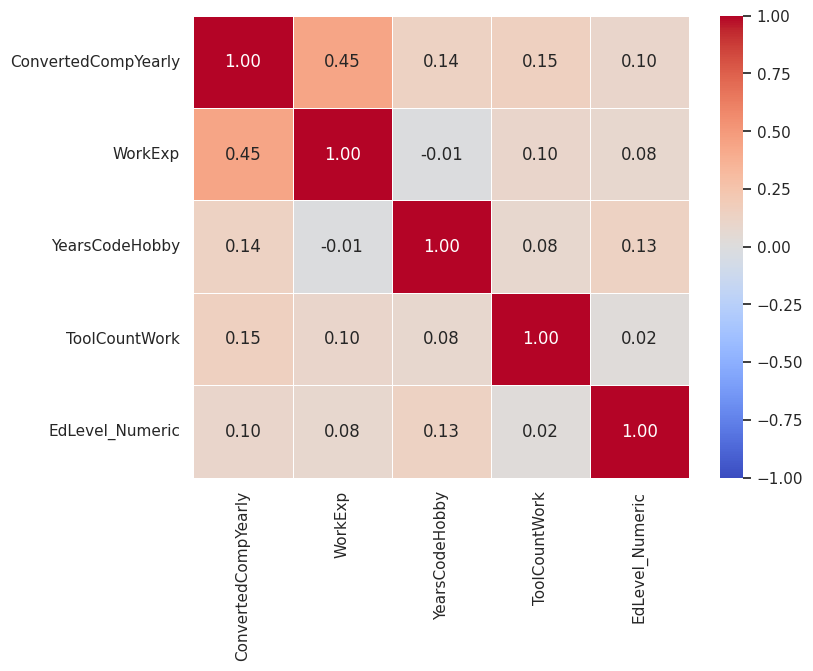

In [60]:
plt.figure(figsize=(8, 6))
corr_cols = [
    "ConvertedCompYearly",
    "WorkExp",
    "YearsCodeHobby",
    "ToolCountWork",
    "EdLevel_Numeric",
]
corr_matrix = df_clean[corr_cols].corr(method="spearman")

sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5
)
plt.show()

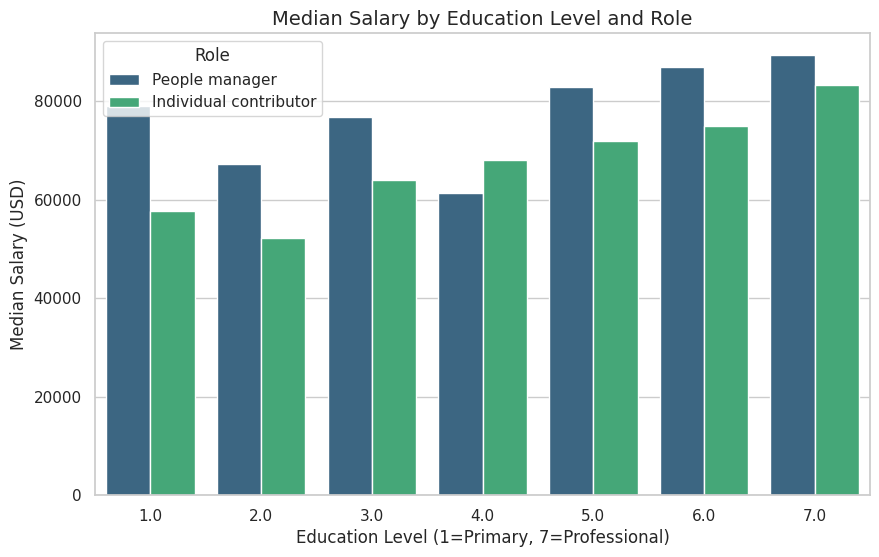

In [61]:
plt.figure(figsize=(10, 6))
role_df = df_clean.dropna(subset=["ICorPM", "EdLevel_Numeric"])

sns.barplot(
    x="EdLevel_Numeric",
    y="ConvertedCompYearly",
    hue="ICorPM",
    data=role_df,
    estimator=np.median,
    palette="viridis",
    errorbar=None,
)
plt.title("Median Salary by Education Level and Role", fontsize=14)
plt.xlabel("Education Level (1=Primary, 7=Professional)")
plt.ylabel("Median Salary (USD)")
plt.legend(title="Role")
plt.show()

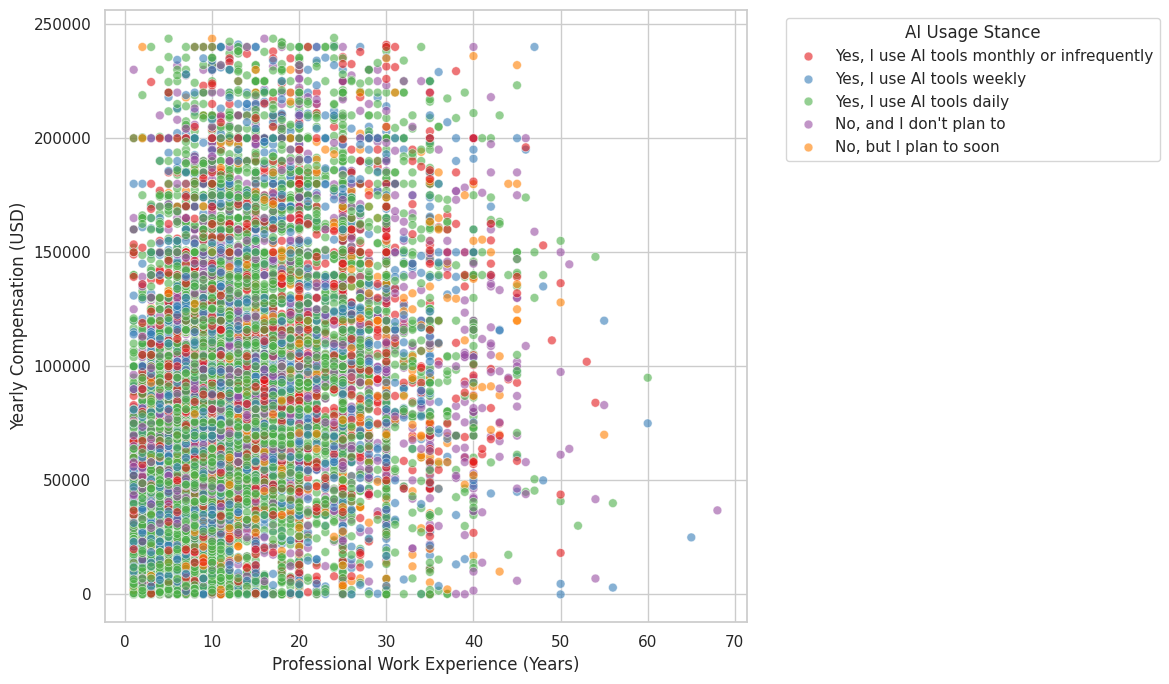

In [62]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x="WorkExp",
    y="ConvertedCompYearly",
    hue="AISelect",
    data=df_clean,
    alpha=0.6,
    palette="Set1",
    s=40,
)
plt.xlabel("Professional Work Experience (Years)")
plt.ylabel("Yearly Compensation (USD)")
plt.legend(title="AI Usage Stance", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

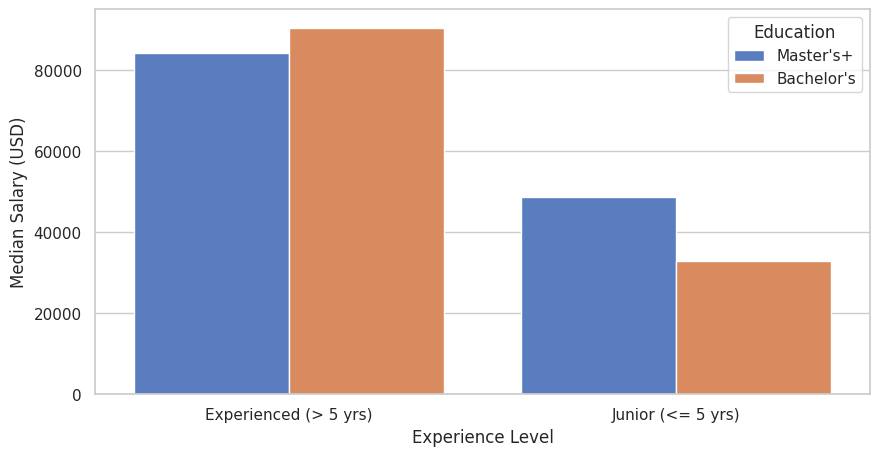

In [63]:
plt.figure(figsize=(10, 5))
plot_df = df_clean[df_clean["EdLevel_Numeric"].isin([5.0, 6.0, 7.0])].copy()
plot_df["Education"] = plot_df["EdLevel_Numeric"].map(
    {5.0: "Bachelor's", 6.0: "Master's+", 7.0: "Master's+"}
)
plot_df["Exp_Category"] = plot_df["WorkExp"].apply(
    lambda x: "Junior (<= 5 yrs)" if x <= 5 else "Experienced (> 5 yrs)"
)

sns.barplot(
    x="Exp_Category",
    y="ConvertedCompYearly",
    hue="Education",
    data=plot_df,
    estimator=np.median,
    palette="muted",
    errorbar=None,
)
plt.xlabel("Experience Level")
plt.ylabel("Median Salary (USD)")
plt.show()

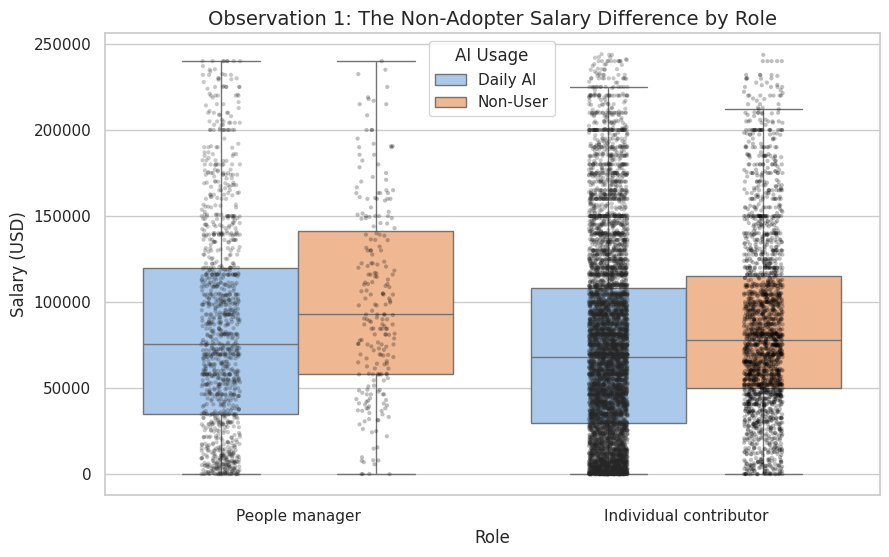

In [64]:
plot_h1 = df_clean[
    (
        df_clean["AISelect"].isin(
            ["Yes, I use AI tools daily", "No, and I don't plan to"]
        )
    )
    & (df_clean["ICorPM"].isin(["Individual contributor", "People manager"]))
].copy()
plot_h1["AI Usage"] = plot_h1["AISelect"].map(
    {"Yes, I use AI tools daily": "Daily AI", "No, and I don't plan to": "Non-User"}
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=plot_h1,
    x="ICorPM",
    y="ConvertedCompYearly",
    hue="AI Usage",
    palette="pastel",
    showfliers=False,
    ax=ax,
)
sns.stripplot(
    data=plot_h1,
    x="ICorPM",
    y="ConvertedCompYearly",
    hue="AI Usage",
    dodge=True,
    palette="dark:black",
    alpha=0.25,
    jitter=True,
    size=3,
    ax=ax,
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="AI Usage")
ax.set_title("Observation 1: The Non-Adopter Salary Difference by Role", fontsize=14)
ax.set_ylabel("Salary (USD)")
ax.set_xlabel("Role")
plt.show()


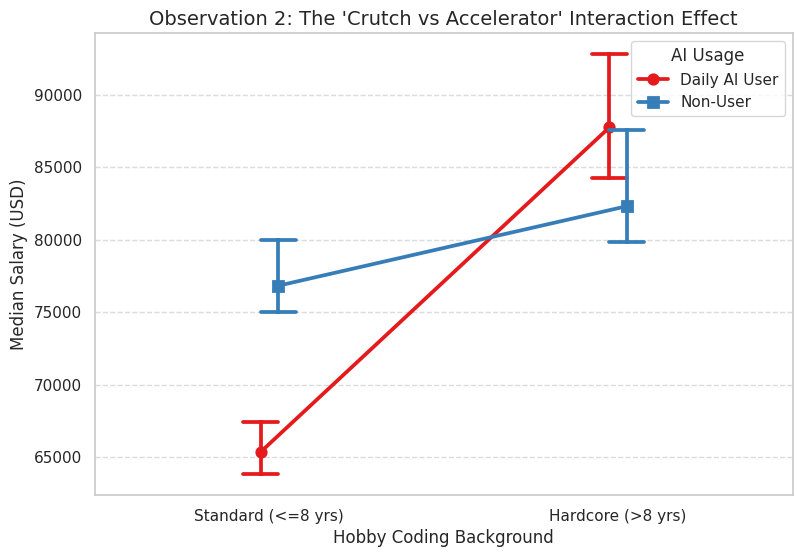

In [65]:
ai_df = df_clean[
    df_clean["AISelect"].isin(["Yes, I use AI tools daily", "No, and I don't plan to"])
].copy()

plot_h2 = ai_df.copy()
plot_h2["Hobby_Background"] = plot_h2["YearsCodeHobby"].apply(
    lambda x: "Hardcore (>8 yrs)" if x > 8 else "Standard (<=8 yrs)"
)
plot_h2["AI_Usage"] = plot_h2["AISelect"].map(
    {
        "Yes, I use AI tools daily": "Daily AI User",
        "No, and I don't plan to": "Non-User",
    }
)

plt.figure(figsize=(9, 6))
sns.pointplot(
    data=plot_h2,
    x="Hobby_Background",
    y="ConvertedCompYearly",
    hue="AI_Usage",
    estimator=np.median,
    errorbar=("ci", 95),
    capsize=0.1,
    palette="Set1",
    dodge=True,
    markers=["o", "s"],
)
plt.title("Observation 2: The 'Crutch vs Accelerator' Interaction Effect", fontsize=14)
plt.xlabel("Hobby Coding Background")
plt.ylabel("Median Salary (USD)")
plt.legend(title="AI Usage")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Now that we have a broad overview of the data, I will test two hypotheses.

## Hypothesis 1

A common assumption is that AI makes developers more valuable.
* **Observation:** Observation 1 shows that median salaries visually appear higher for non-AI users across both Individual Contributors and People Managers.
* **Null Hypothesis (H0):** There is no significant difference in the median annual compensation between daily AI users and non-users within a given role.
* **Test Chosen:** Mann-Whitney U test. As shown by the initial Salary Histogram, compensation is heavily right-skewed (non-normal). Therefore, we use a non-parametric test to compare the distributions of two independent groups.

In [66]:
ai_users = df_clean[df_clean["AISelect"] == "Yes, I use AI tools daily"]
non_ai_users = df_clean[df_clean["AISelect"] == "No, and I don't plan to"]

ic_ai = ai_users[ai_users["ICorPM"] == "Individual contributor"][
    "ConvertedCompYearly"
].dropna()
ic_non = non_ai_users[non_ai_users["ICorPM"] == "Individual contributor"][
    "ConvertedCompYearly"
].dropna()

print("\tIndividual Contributors")
print(
    f"Median Salary | Non-User: ${ic_non.median():,.0f} vs AI Daily: ${ic_ai.median():,.0f}"
)

stat_ic, p_ic = stats.mannwhitneyu(ic_non, ic_ai, alternative="greater")
print(f"p-value: {p_ic:.4e}")
if p_ic < 0.05:
    print(
        "Conclusion: Reject H0. Non-using ICs earn a statistically significant premium over AI-using ICs.\n"
    )
else:
    print("Conclusion: Fail to reject H0.\n")

	Individual Contributors
Median Salary | Non-User: $78,011 vs AI Daily: $68,131
p-value: 1.2366e-22
Conclusion: Reject H0. Non-using ICs earn a statistically significant premium over AI-using ICs.



In [67]:
pm_ai = ai_users[ai_users["ICorPM"] == "People manager"]["ConvertedCompYearly"].dropna()
pm_non = non_ai_users[non_ai_users["ICorPM"] == "People manager"][
    "ConvertedCompYearly"
].dropna()

print("\tPeople Managers")
print(
    f"Median Salary | Non-User: ${pm_non.median():,.0f} vs AI Daily: ${pm_ai.median():,.0f}"
)
stat_pm, p_pm = stats.mannwhitneyu(pm_non, pm_ai, alternative="greater")
print(f"p-value: {p_pm:.4e}")
if p_pm < 0.05:
    print(
        "Conclusion: Reject H0. Non-using Managers earn a statistically significant premium over AI-using Managers.\n"
    )
else:
    print("Conclusion: Fail to reject H0.\n")

	People Managers
Median Salary | Non-User: $92,812 vs AI Daily: $75,410
p-value: 2.2026e-05
Conclusion: Reject H0. Non-using Managers earn a statistically significant premium over AI-using Managers.



The data proved the opposite of the initial hypothesis. **Refusing to use AI tools provides a statistically significant salary premium** for both Individual Contributors and People Managers. 

## Hypothesis 2

* **Observation:** Observation 2 shows a visual "flip" (interaction effect): daily AI usage correlates with lower pay for standard hobbyists (<= 8 yrs), but correlates with higher pay for hardcore hobbyists (> 8 yrs).
* **Null Hypothesis (H0):** Pre-professional hobby experience does not alter the salary impact of AI usage (i.e., AI users do not earn significantly more or less than non-users in either hobbyist tier).
* **Test Chosen:** Mann-Whitney U test.

In [68]:
std_hobby = ai_df[ai_df["YearsCodeHobby"] <= 8]
ai_std = std_hobby[std_hobby["AISelect"] == "Yes, I use AI tools daily"][
    "ConvertedCompYearly"
].dropna()
non_std = std_hobby[std_hobby["AISelect"] == "No, and I don't plan to"][
    "ConvertedCompYearly"
].dropna()

print("\tStandard Hobbyists (<= 8 Years Hobby Coding)")
print(
    f"Median Salary | AI Daily: ${ai_std.median():,.0f} vs Non-User: ${non_std.median():,.0f}"
)

stat_std, p_std = stats.mannwhitneyu(non_std, ai_std, alternative="greater")
print(f"p-value: {p_std:.4e}")
if p_std < 0.05:
    print("Conclusion: Reject H0. Non-users earn more.\n")
else:
    print("Conclusion: Fail to reject H0.\n")

	Standard Hobbyists (<= 8 Years Hobby Coding)
Median Salary | AI Daily: $65,348 vs Non-User: $76,825
p-value: 1.4192e-24
Conclusion: Reject H0. Non-users earn more.



In [69]:
hdc_hobby = ai_df[ai_df["YearsCodeHobby"] > 8]
ai_hard = hdc_hobby[hdc_hobby["AISelect"] == "Yes, I use AI tools daily"][
    "ConvertedCompYearly"
].dropna()
non_hard = hdc_hobby[hdc_hobby["AISelect"] == "No, and I don't plan to"][
    "ConvertedCompYearly"
].dropna()

print("\tHardcore Hobbyists (> 8 Years Hobby Coding)")
print(
    f"Median Salary | AI Daily: ${ai_hard.median():,.0f} vs Non-User: ${non_hard.median():,.0f}"
)
stat_hard, p_hard = stats.mannwhitneyu(ai_hard, non_hard, alternative="greater")
print(f"p-value: {p_hard:.4e}")
if p_hard < 0.05:
    print("Conclusion: Reject H0. AI users earn more.\n")
else:
    print("Conclusion: Fail to reject H0.\n")

	Hardcore Hobbyists (> 8 Years Hobby Coding)
Median Salary | AI Daily: $87,763 vs Non-User: $82,319
p-value: 5.5108e-02
Conclusion: Fail to reject H0.



The data showed that:  
- For developers with a standard background (<= 8 years of pre-professional hobby coding), daily AI usage is associated with significantly *lower* pay, suggesting it may act as a "crutch" for less experienced developers.
- For hardcore hobbyists, the difference between earnings of daily ai users and non-users is not statistically significant. Although, it shows a strong trend that AI acts as an accelerator for senior devs, reversing the 'crutch' penalty seen in junior hobbyists.

## Discussion

**What I did and why:**
- Performed data cleanup by dropping missing values in critical columns, and applying the IQR method to remove extreme outliers.
- Computed descriptive stats (mean, median, std) for 4+ numerical fields and created multiple plot types (histograms, boxplots, line plots, scatterplots) for initial exploration of distributions.
- Added 2 transformed columns: `YearsCodeHobby` (subtracting professional experience from total coding years) and `EdLevel_Numeric` (ordinal mapping of education levels) to enable categorical grouping and quantitative hypothesis testing.
- For detailed overview: used comparisons with hue, side-by-side subplot visualizations, and a Spearman correlation heatmap to reveal interactions (e.g., work vs. personal tool usage, correlation between experience and pay).
- Tested 2 hypotheses
- All plots were created using Matplotlib/Seaborn.